# 🛍️ Customer Segmentation using RFM Analysis & K-Means Clustering

## 📋 Project Overview
This project focuses on **Customer Segmentation** for an online retail business using the powerful **RFM (Recency, Frequency, Monetary)** model combined with **K-Means Clustering**. The goal is to identify distinct customer groups to enable targeted marketing strategies and improve customer relationship management.

**Data Link**:  
[📥 Download from UCI](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
---

## 🎯 Business Task
- Perform **RFM Analysis** to score customers.
- Apply **unsupervised machine learning** (K-Means) to segment customers into meaningful groups.
- Provide actionable marketing insights for each segment.

---

## 🛠️ What I Did

### 1. Data Preprocessing
- Handled missing values and cancelled orders
- Removed outliers and irrelevant entries
- Calculated **RFM features**:
  - **Recency**: Days since last purchase
  - **Frequency**: Number of transactions per customer
  - **Monetary**: Total spending per customer
- Applied **Log Transformation** + **Standard Scaling**

### 2. Modeling
- Used **K-Means Clustering**
- Determined optimal number of clusters using **Elbow Method** and **Silhouette Score**
- Final Model: **K-Means (4 Clusters)** with **Silhouette Score = 0.33**

### 3. Visualization & Evaluation
- 3D Scatter Plot (Recency, Frequency, Monetary)
- Cluster profiling and interpretation
- Business insights and marketing recommendations
---

## 🚀 Project Highlights
- Real-world transactional dataset
- Strong business interpretation of clusters
- Interactive 3D visualization
- Actionable marketing recommendations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Read The Data
retail = pd.read_excel(r"Data\online_retail_II.xlsx")
retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [3]:
retail.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,525461.0,10.337667,-9600.0,1.0,3.0,10.0,19152.0,107.42411
InvoiceDate,525461,2010-06-28 11:37:36.845018,2009-12-01 07:45:00,2010-03-21 12:20:00,2010-07-06 09:51:00,2010-10-15 12:45:00,2010-12-09 20:01:00,NaN
Price,525461.0,4.688834,-53594.36,1.25,2.1,4.21,25111.09,146.126914
Customer ID,417534.0,15360.645478,12346.0,13983.0,15311.0,16799.0,18287.0,1680.811316


In [4]:
# Proportion of null values for each column
retail.isnull().sum() / len(retail) * 100

Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64

In [5]:
# Delete the null values in 'Customer' ID column
retail = retail.dropna(subset=['Customer ID'])

In [6]:
# Remove cancelled orders (Invoice numbers starting with 'C')
retail = retail.loc[~retail['Invoice'].str.startswith('C', na=False)]

In [7]:
# Check for duplicates
retail.duplicated().sum()

np.int64(6748)

In [8]:
# Remove duplicates
retail = retail.drop_duplicates()

In [9]:
# Create 'total price' column
retail['total price'] = retail['Quantity'] * retail['Price']

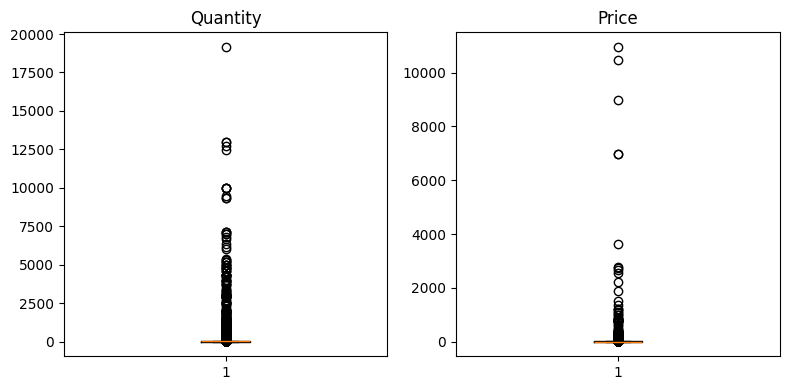

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2)

plt.gcf().set_size_inches(8, 4)
axes[0].boxplot(retail['Quantity'])
axes[1].boxplot(retail['Price'])

axes[0].set_title("Quantity")
axes[1].set_title('Price')

plt.tight_layout()
plt.show()

In [11]:
"""
After analyzing outliers, we found a very small number of extreme values:
- Quantity exceeding 7,500 units
- UnitPrice exceeding 4,000

Capping these two columns is the best approach to handle these outliers 
without losing too much data.
"""

retail = retail.loc[(retail['Price'] < 2000) & (retail['Quantity'] < 7500)]

In [12]:
len(retail)

400924

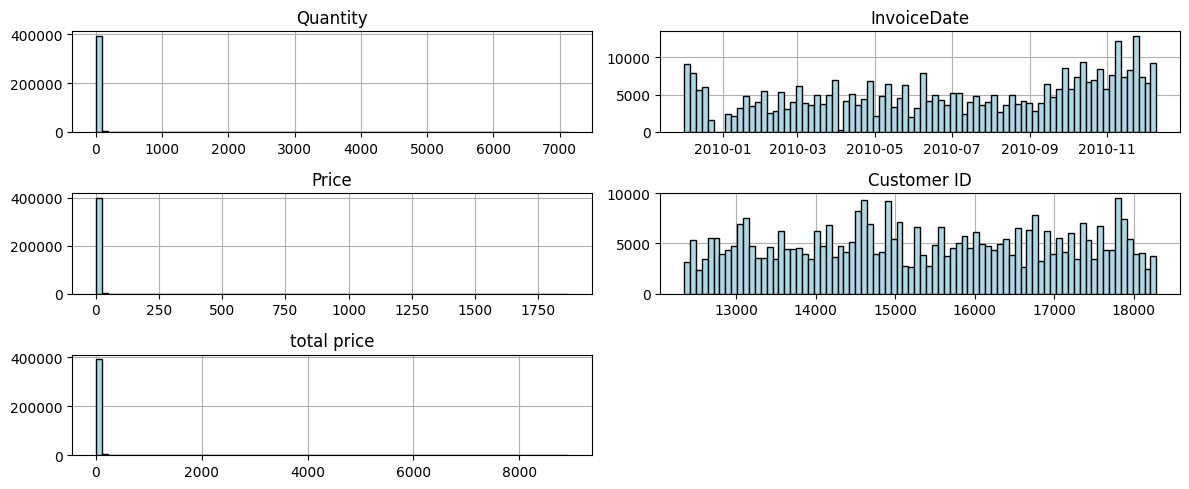

In [13]:
# Plot Histograms to show distribution for each numeric column
retail.hist(bins=80, edgecolor='black', color='lightblue', figsize=(12, 5), zorder=5)
plt.tight_layout()
plt.show()

In [14]:
# Set the 'InvoiceDate' column as an index
retail = retail.set_index(retail['InvoiceDate'])
retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,total price
InvoiceDate,,,,,,,,,
2009-12-01 07:45:00,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
2009-12-01 07:45:00,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2009-12-01 07:45:00,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2009-12-01 07:45:00,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
2009-12-01 07:45:00,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


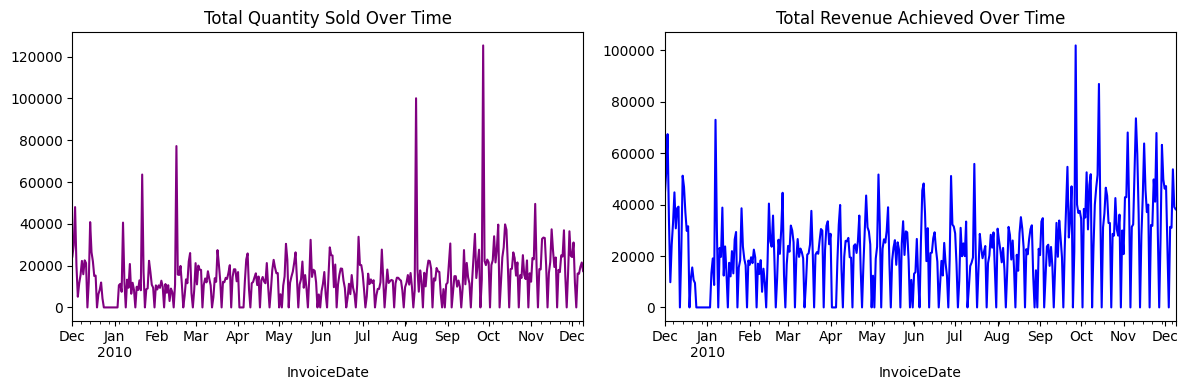

In [15]:
# Daily Total Quantity Sold & Total Revenue Acheived Over Time
fig, axes = plt.subplots(nrows=1, ncols=2)

plt.gcf().set_size_inches(12, 4)
retail.resample("D")['Quantity'].sum().plot(kind='line', ax=axes[0], color='purple')
retail.resample("D")['total price'].sum().plot(kind='line', ax=axes[1], color='blue')

axes[0].set_title("total quantity sold over time".title())
axes[1].set_title('total revenue achieved over time'.title())

plt.tight_layout()
plt.show()

In [16]:
print(f"Total Reveue: {retail['total price'].sum():,.2f}$")
print(f"Total Quanity Sold: {retail['Quantity'].sum():,.2f}")

Total Reveue: 8,700,738.04$
Total Quanity Sold: 5,382,013.00


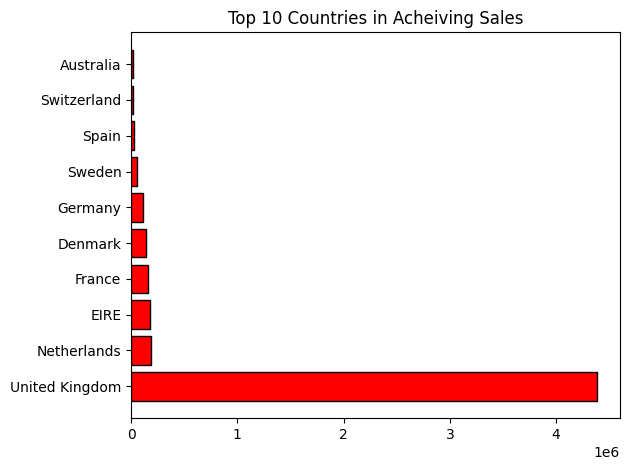

In [17]:
country_grouped = retail.groupby("Country")['Quantity'].sum().sort_values(ascending=False).iloc[:10]

plt.barh(country_grouped.index, country_grouped.values, color='red', edgecolor='black')
plt.title("Top 10 Countries in Acheiving Sales")
plt.tight_layout()
plt.show()

In [18]:
# Frequency column
freq = retail.drop_duplicates(subset=['Invoice'])
freq = freq.groupby("Customer ID")['Invoice'].count().sort_values(ascending=False)

# Recency column
last_date = retail.index.max()
recency = (last_date - retail.groupby("Customer ID")['InvoiceDate'].max()).dt.days

# monetary column
monetary = retail.groupby("Customer ID")['total price'].sum()

In [19]:
# Create the rfm_df
rfm_df = pd.concat([freq, recency, monetary], axis=1)
rfm_df.columns = ['frequency', 'recency', 'monetary']
rfm_df.head()

,frequency,recency,monetary
Customer ID,,,
14911.0,205,0,152121.22
17850.0,155,7,51208.87
12748.0,144,0,22457.90
15311.0,121,0,55942.74
13089.0,109,3,57885.45


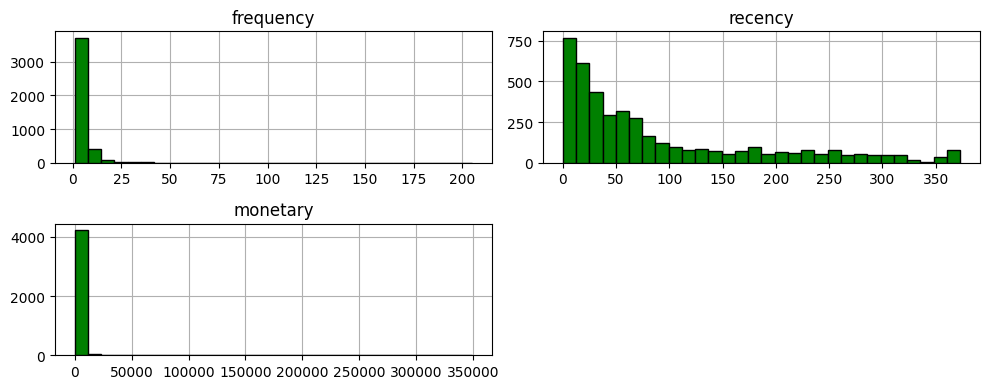

In [20]:
# Show Distribution of rfm df
rfm_df.hist(edgecolor='black', color='green', figsize=(10, 4), bins=30, zorder=5)
plt.tight_layout()
plt.show()

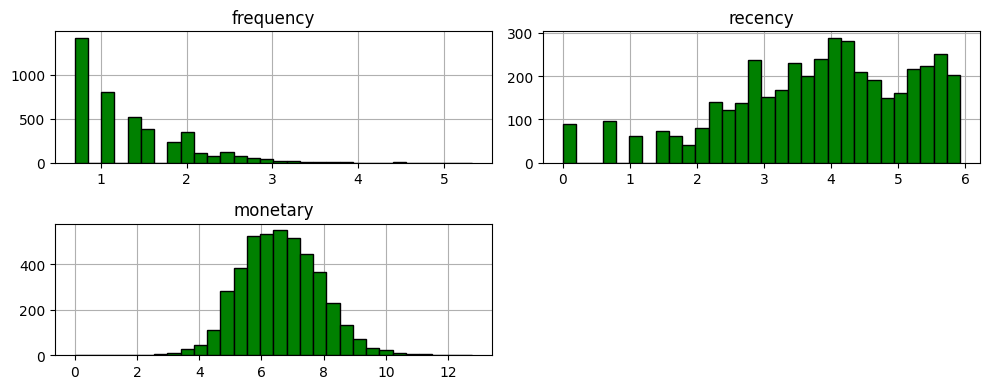

In [21]:
"""
After analyzing the distributions of the RFM features in rfm_df, 
I noticed that all columns (Recency, Frequency, and Monetary) 
are positively skewed.

Since K-Means and most machine learning algorithms perform better 
with normally distributed data, I will apply log transformation 
to reduce the skewness.
"""

rfm_log_clean = rfm_df.apply(lambda x: np.log1p(x))
rfm_log_clean.hist(edgecolor='black', color='green', figsize=(10, 4), bins=30, zorder=5)
plt.tight_layout()
plt.show()

In [22]:
# Save the rfm data as a csv file
rfm_df.to_csv(r"Data\rfm_data.csv")

In [23]:
# Scaling the Data
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_scaled = scalar.fit_transform(rfm_log_clean)

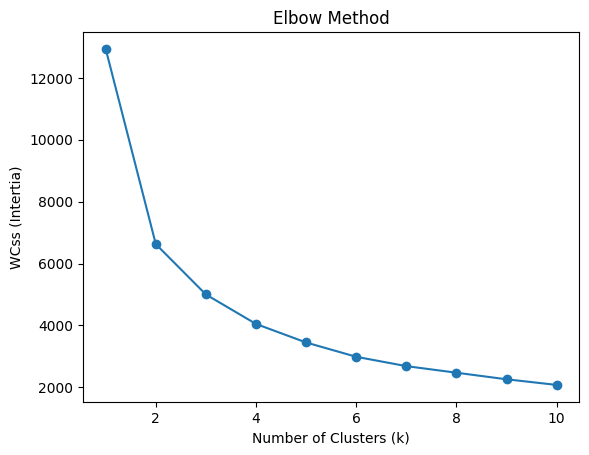

In [24]:
"""====================== Elbow Method for Optimal K ======================
I used the Elbow Method to determine the optimal number of clusters (k)
by calculating the Within-Cluster Sum of Squares (WCSS) for k from 1 to 10.

The "elbow" point in the plot indicates where adding more clusters 
gives diminishing returns in reducing WCSS."""

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCss (Intertia)")
plt.show()

In [25]:
# Fit K-Means with 4 clusters and calculate Silhouette Score to evaluate clustering quality
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

print(f"silhouette score: {silhouette_score(X_scaled, kmeans.labels_)}")

silhouette score: 0.33015184573897843


In [26]:
# Fit DBSCAN with epsilon 0.6 and min sampeles 12 and calculate the Silhouette Score
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.6, min_samples=13)
labels = db.fit_predict(X_scaled)

print(f"silhouette score: {silhouette_score(X_scaled, labels)}")

silhouette score: 0.5152366850033209


In [27]:
labels = db.labels_

print(f"Unique labels: {np.unique(labels)}")

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters: {n_clusters}")

Unique labels: [-1  0]
Number of clusters: 1


In [28]:
# Fit Aggolomerative clustering with number of clusters 4 and calculate the Silhouette Score
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = model.fit_predict(X_scaled)

print(f"silhouette score: {silhouette_score(X_scaled, labels)}")

silhouette score: 0.2860003102212275


In [29]:
df_rfm = pd.DataFrame(X_scaled, columns=['Frequency', 'Recency', 'Monetary'])
df_rfm['Cluster'] = kmeans.labels_

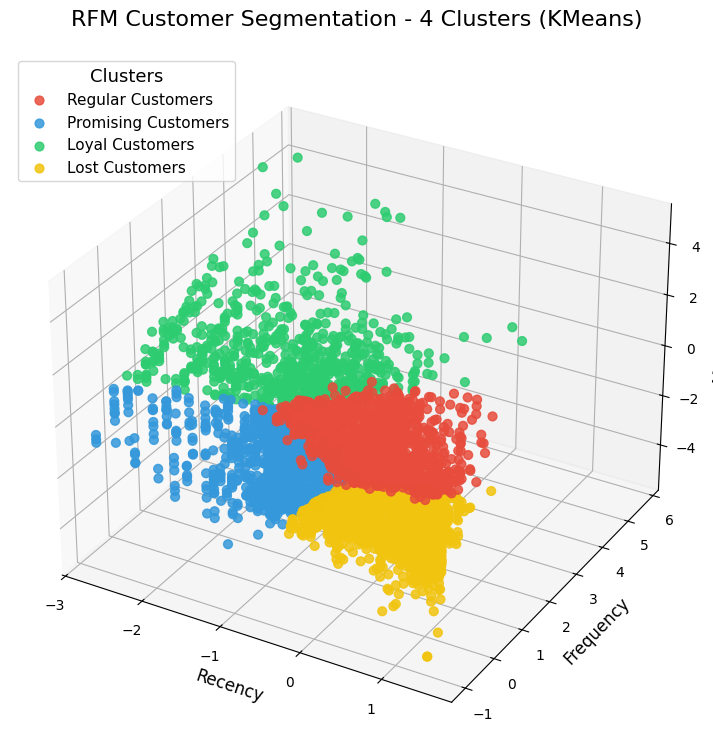

In [30]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Convert nd array to a DataFrame
df_rfm = pd.DataFrame(X_scaled, columns=['Frequency', 'Recency', 'Monetary'])
df_rfm['Cluster'] = kmeans.labels_ 

# Mapping 
cluster_names = {
    0: 'Regular Customers',
    1: 'Promising Customers',
    2: 'Loyal Customers',
    3: 'Lost Customers'
}
df_rfm['Cluster_Name'] = df_rfm['Cluster'].map(cluster_names)


# Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f']

for i in range(4):
    cluster_data = df_rfm[df_rfm['Cluster'] == i]
    
    ax.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        c=colors[i],
        label=cluster_names[i],
        s=40,
        alpha=0.85
    )

ax.set_xlabel('Recency', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_zlabel('Monetary', fontsize=12)
ax.set_title('RFM Customer Segmentation - 4 Clusters (KMeans)', fontsize=16, pad=20)

ax.legend(title="Clusters", title_fontsize=13, fontsize=11, loc='upper left')
plt.show()

In [31]:
df_rfm['Cluster_Name'].value_counts(normalize=True) * 100

Cluster_Name
Lost Customers         34.322820
Regular Customers      28.594620
Promising Customers    20.570501
Loyal Customers        16.512059
Name: proportion, dtype: float64

## 📈 Results & Customer Segments

| Segment                  | Recency     | Frequency     | Monetary     | % of Customers | Marketing Strategy                  |
|-------------------------|-------------|---------------|--------------|----------------|-------------------------------------|
| **Loyal Customers** (Green)   | Mixed       | Very High     | Medium-High  | ~16%        | VIP Programs & Loyalty Rewards      |
| **Frequent Low-Spenders** (Red) | Medium   | High          | Low          | ~28%        | Upsell & Bundle Offers              |
| **Promising / New** (Blue)   | Low         | Low-Medium    | Low          | ~20%           | Welcome Offers & Engagement         |
| **Lost Customers** (Yellow)  | High        | Low-Medium    | Low          | ~34%        | Win-Back Campaigns                  |

In [32]:
df_rfm['Cluster_Name'].value_counts()

Cluster_Name
Lost Customers         1480
Regular Customers      1233
Promising Customers     887
Loyal Customers         712
Name: count, dtype: int64